<a href="https://colab.research.google.com/github/nivishh/BARCLAYS-BANK-CHURN-ANALYSIS/blob/main/BARCLAYS_BANK_CHURN_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project objective Barclays bank facing high customer churn rate, and customer not keep using sevices, being a Data scientist your task is to identify the companies problem so that they can get the real time insights and management can take decision accordingly, previously banks were not getting timely insights and did not take decision timely, taht costs high customer churn rate, the previous methodologies were old and not upto dated,presently bank needs live analysis and corrective measures to predict the future churn rates and live analysis

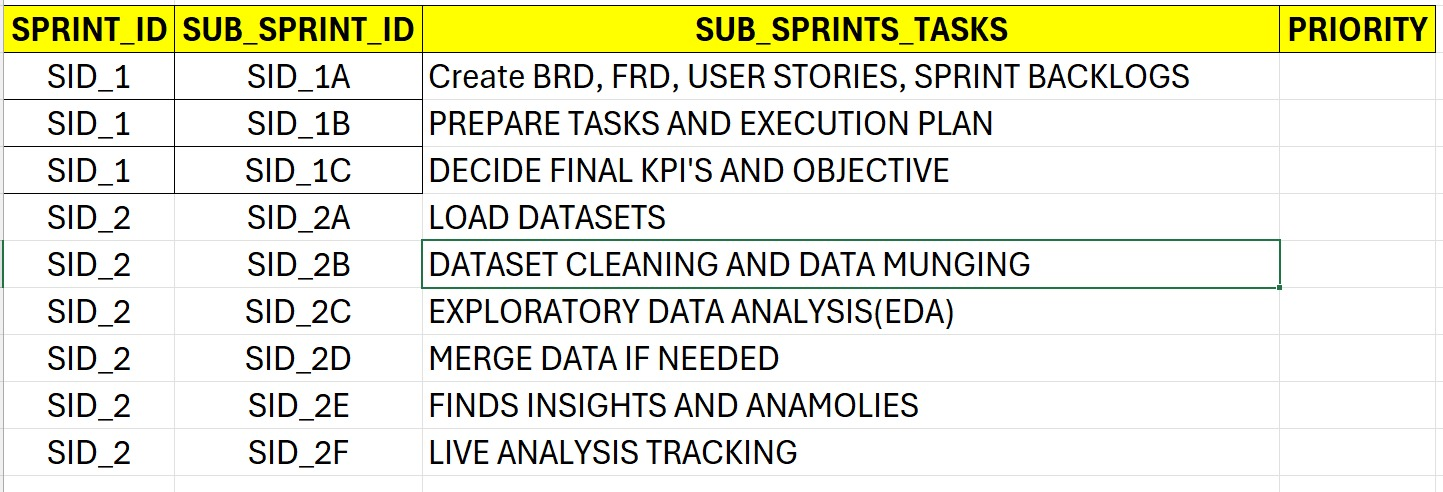

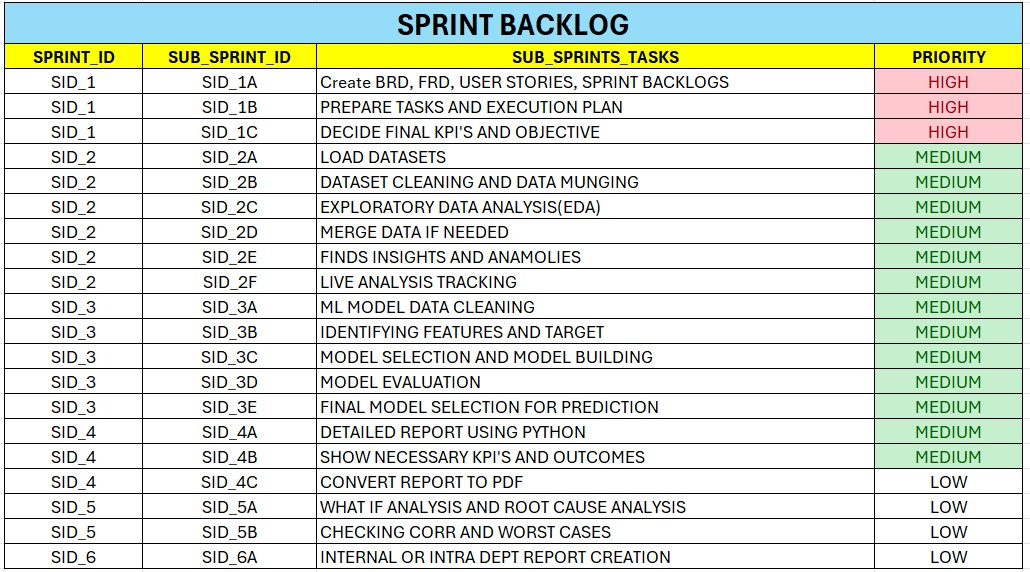

STEP 1: Load Important Modules

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, recall_score
import pickle
import IPython as ip
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')

print("All Modules Loaded Successfully!!")



All Modules Loaded Successfully!!


STEP 2: Load Datasets


In [ ]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/ActiveCustomer.xlsx"
active_customer_df = pd.read_excel(url)
print("done")

done


In [ ]:
url ="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/CreditCard.xlsx"
credit_card_df= pd.read_excel(url)
print("done")

done


In [ ]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/ExitCustomer.xlsx"
exit_customer_df = pd.read_excel(url)
print("done")

done


In [ ]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Gender.xlsx"
gender_df = pd.read_excel(url)
print("done")

done


In [ ]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Geography.xlsx"
geography_df = pd.read_excel(url)
print("done")

done


In [ ]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Bank_Churn.csv"
bank_churn_df = pd.read_csv(url)
print("done")

done


In [ ]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/CustomerInfo.csv"
customer_info_df = pd.read_csv(url)
print("done")

done


In [ ]:

all_dfs = [active_customer_df,
          credit_card_df,
          exit_customer_df,
          gender_df,
          geography_df,
          bank_churn_df,
          customer_info_df]
for i in all_dfs:
  print('='*50)
  display(i.sample(2))

,ActiveID,ActiveCategory
1,0,Inactive Member
0,1,Active Member


,CreditID,Category
1,0,non credit card holder
0,1,credit card holder


,ExitID,ExitCategory
0,1,Exit
1,0,Retain


,GenderID,GenderCategory
0,1,Male
1,2,Female


,GeographyID,GeographyLocation
1,2,Spain
0,1,France


,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ
3506,3507,15806511,445,2,1,45,4,0.00,2,0,1,90977.48,0,08-11-2018
4375,4376,15616555,850,3,1,41,3,60880.68,1,1,0,31825.84,0,29-09-2019


,CustomerId,Surname
7558,15642098,Cox
1344,15691104,Kennedy


STEP 3: EDA(Exploratory data Analysis)

In [ ]:
# step 3.2: show df shape size
bank_churn_df.sample(5)

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ
5655,5656,15573171,695,2,1,63,4,146202.93,1,1,1,126688.83,1,20-05-2019
9758,9759,15701160,556,3,2,43,5,125890.72,1,1,1,74854.97,0,28-03-2018
7634,7635,15707681,501,3,1,38,3,88977.39,2,0,1,133403.07,0,23-09-2019
614,615,15660271,688,3,1,26,3,146133.39,1,1,1,175296.76,0,31-12-2019
3654,3655,15632365,542,3,1,33,6,142871.27,2,0,0,77737.86,0,19-04-2017


In [ ]:
# step 3.2: show df shape size
bank_churn_df.shape

# 14 columns and 10k rows


(10000, 14)

In [ ]:
bank_churn_df.size

140000

In [ ]:
# combine all dfs
merged_df = pd.merge(bank_churn_df, customer_info_df , on = 'CustomerId')
merged_df = pd.merge(merged_df,geography_df, on = 'GeographyID')
final_df = pd.merge(merged_df, gender_df, on = 'GenderID')
final_df


,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory
0,1,15634602,619,1,2,42,7,0.00,1,1,1,101348.88,1,23-03-2016,Hargrave,France,Female
1,2,15647311,608,2,2,41,4,83807.86,1,0,1,112542.58,0,09-10-2018,Hill,Spain,Female
2,3,15619304,502,1,2,42,4,159660.80,3,1,0,113931.57,1,25-03-2019,Onio,France,Female
3,4,15701354,699,1,2,39,3,0.00,2,0,0,93826.63,0,24-10-2019,Boni,France,Female
4,5,15737888,850,2,2,43,3,125510.82,1,1,1,79084.10,0,22-11-2019,Mitchell,Spain,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,1,1,39,5,0.00,2,1,0,96270.64,0,25-03-2018,Obijiaku,France,Male
9996,9997,15569892,516,1,1,35,5,57369.61,1,1,1,101699.77,0,17-06-2018,Johnstone,France,Male
9997,9998,15584532,709,1,2,36,5,0.00,1,0,1,42085.58,1,18-03-2018,Liu,France,Female
9998,9999,15682355,772,3,1,42,3,75075.31,2,1,0,92888.52,1,12-11-2019,Sabbatini,Germany,Male


In [ ]:
final_df.shape

(10000, 17)

In [ ]:
# step 3.4
# show column info
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RowNumber          10000 non-null  int64  
 1   CustomerId         10000 non-null  int64  
 2   CreditScore        10000 non-null  int64  
 3   GeographyID        10000 non-null  int64  
 4   GenderID           10000 non-null  int64  
 5   Age                10000 non-null  int64  
 6   Tenure             10000 non-null  int64  
 7   Balance            10000 non-null  float64
 8   NumOfProducts      10000 non-null  int64  
 9   HasCrCard          10000 non-null  int64  
 10  IsActiveMember     10000 non-null  int64  
 11  EstimatedSalary    10000 non-null  float64
 12  Exited             10000 non-null  int64  
 13  Bank DOJ           10000 non-null  object 
 14  Surname            10000 non-null  object 
 15  GeographyLocation  10000 non-null  object 
 16  GenderCategory     1000

In [ ]:
# 3.5: Drop Nan or missing values
final_df.dropna(inplace= True)
print("done")

done


In [ ]:
# 3.6 show data stats
final_df.describe(include = 'number')

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,1.749500,1.454300,38.921800,4.86430,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,0.830433,0.497932,10.487806,1.21525,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,1.000000,1.000000,18.000000,3.00000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,1.000000,1.000000,32.000000,4.00000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,1.000000,1.000000,37.000000,5.00000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,3.000000,2.000000,44.000000,6.00000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,3.000000,2.000000,92.000000,7.00000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# 3.7: show categorical data stats
final_df.describe (include = 'object')

,Bank DOJ,Surname,GeographyLocation,GenderCategory
count,10000,10000,10000,10000
unique,1332,2932,3,2
top,16-12-2017,Smith,France,Male
freq,35,32,5014,5457


In [ ]:
# 3.8 show datacorrelation
corr = final_df.corr(numeric_only= True)
corr
# corr range from
# -1 to +1
# -1 : represents: Highly Negative correlation
# +1 : represents: Highly positive correlation
# 0 : represents : no correlation

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,-0.005196,-0.018196,0.000783,0.002901,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.000821,0.002641,0.009497,0.003884,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,0.008267,0.002857,-0.003965,-0.007355,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
GeographyID,-0.005196,0.000821,0.008267,1.000000,0.016936,0.048092,-0.003858,0.348700,-0.006180,0.004036,-0.012692,0.007382,0.153771
GenderID,-0.018196,0.002641,0.002857,0.016936,1.000000,0.027544,-0.008018,-0.012087,0.021859,-0.005766,-0.022544,0.008112,0.106512
Age,0.000783,0.009497,-0.003965,0.048092,0.027544,1.000000,0.010788,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.002901,0.003884,-0.007355,-0.003858,-0.008018,0.010788,1.000000,0.001457,-0.029927,0.003857,-0.007576,0.005744,0.000699
Balance,-0.009067,-0.012419,0.006268,0.348700,-0.012087,0.028308,0.001457,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.006180,0.021859,-0.030680,-0.029927,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,0.004036,-0.005766,-0.011721,0.003857,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138


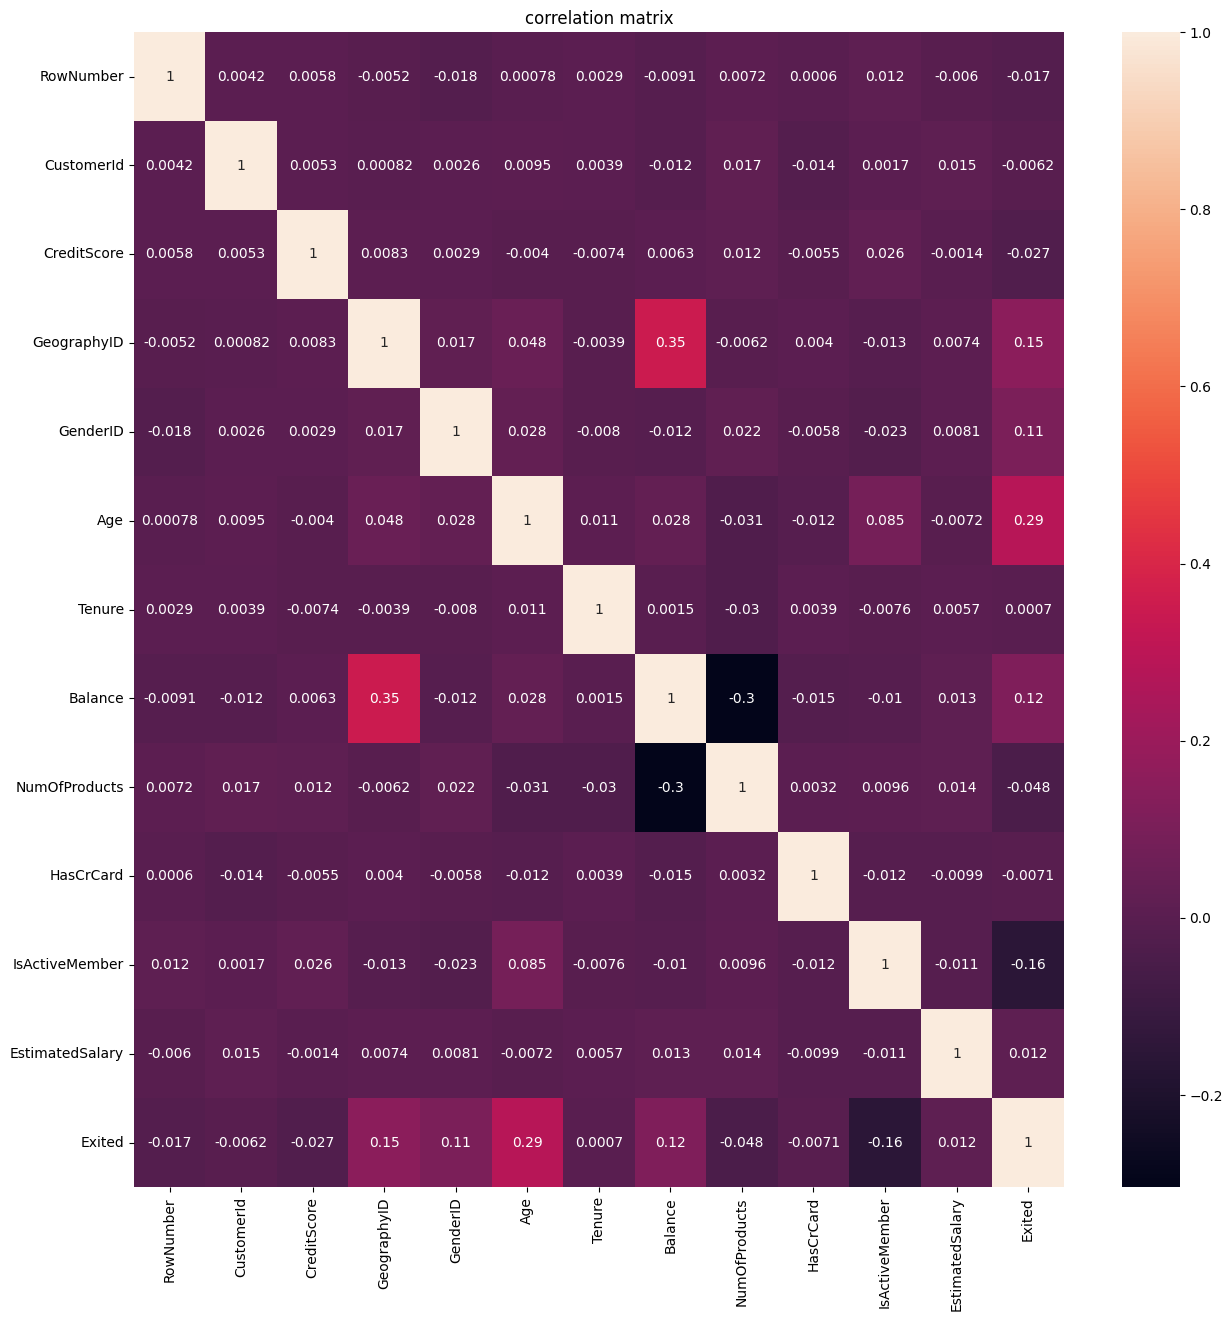

In [ ]:
# 3.9
plt.figure(figsize = (15,15))
plt.title("correlation matrix")
sns.heatmap(corr,annot = True)
plt.show()

In [ ]:
 # step 3.10 Divide Columns into required objects

textual_columns=final_df.select_dtypes('object').columns
numerical_columns= final_df.select_dtypes('number').columns
print("textual Columns: \n",textual_columns)
print('='*100)
print("Numerical Columns: \n",numerical_columns)

textual Columns: 
 Index(['Surname', 'GeographyLocation', 'GenderCategory'], dtype='object')
Numerical Columns: 
 Index(['CustomerId', 'CreditScore', 'GeographyID', 'GenderID', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')


In [ ]:
# step 3.11: change bank DOJ to datetime Dype
final_df['Bank DOJ']= pd.to_datetime(final_df['Bank DOJ'])
print("done")

done


In [ ]:
# step 3.12 Drop Unwanted columns

final_df.drop('RowNumber', axis =1 ,inplace = True)
# axis =1 : means: drop column, axis: drop row
# inplace = True; means: apply changes in original dataset
print ("done")

done


In [ ]:
final_df.columns


Index(['CustomerId', 'CreditScore', 'GeographyID', 'GenderID', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Bank DOJ', 'Surname', 'GeographyLocation',
       'GenderCategory'],
      dtype='object')

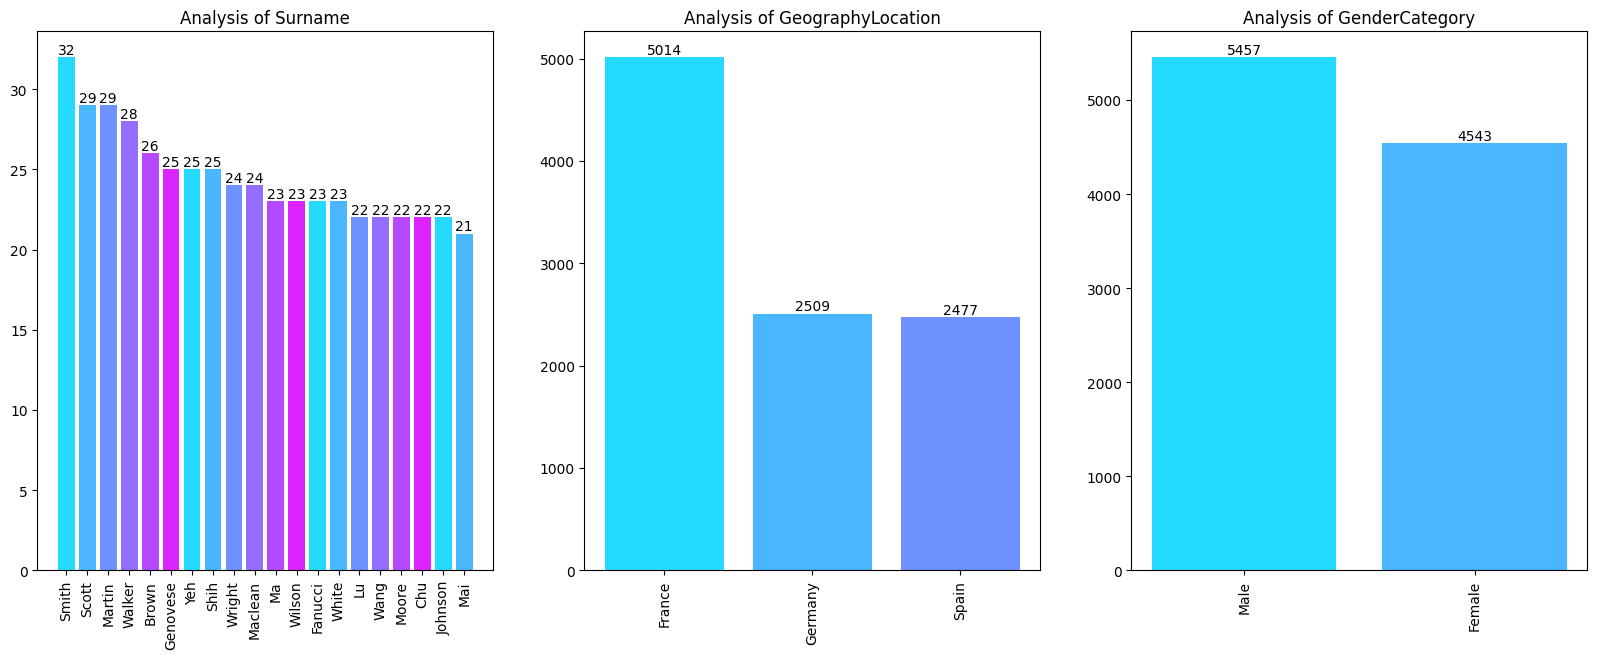

In [ ]:
# 3.13: Univariate Analysis
# means : single columns analysis

# 3.13: Univariate Analysis
# means: single columns analysis

plt.figure(figsize=(20, 7))

for i, j in enumerate(textual_columns):
    plt.subplot(1, 3, i + 1)
    temp_df = final_df[j].value_counts().head(20)
    x = temp_df.index
    y = temp_df.values
    plt.title(f"Analysis of {j}")
    ax = plt.bar(x, y, color=sns.color_palette('cool'))
    plt.bar_label(ax)
    plt.xticks(rotation=90)

plt.show()

# plt.show: out of loop hai
# subplot: plot multiple plots at once
# i: is index
# j: is column name
# enumerate: to get index and value at same time
# value_counts: to grouped data and count its value frequency
# sns.color_palette: to change color shades

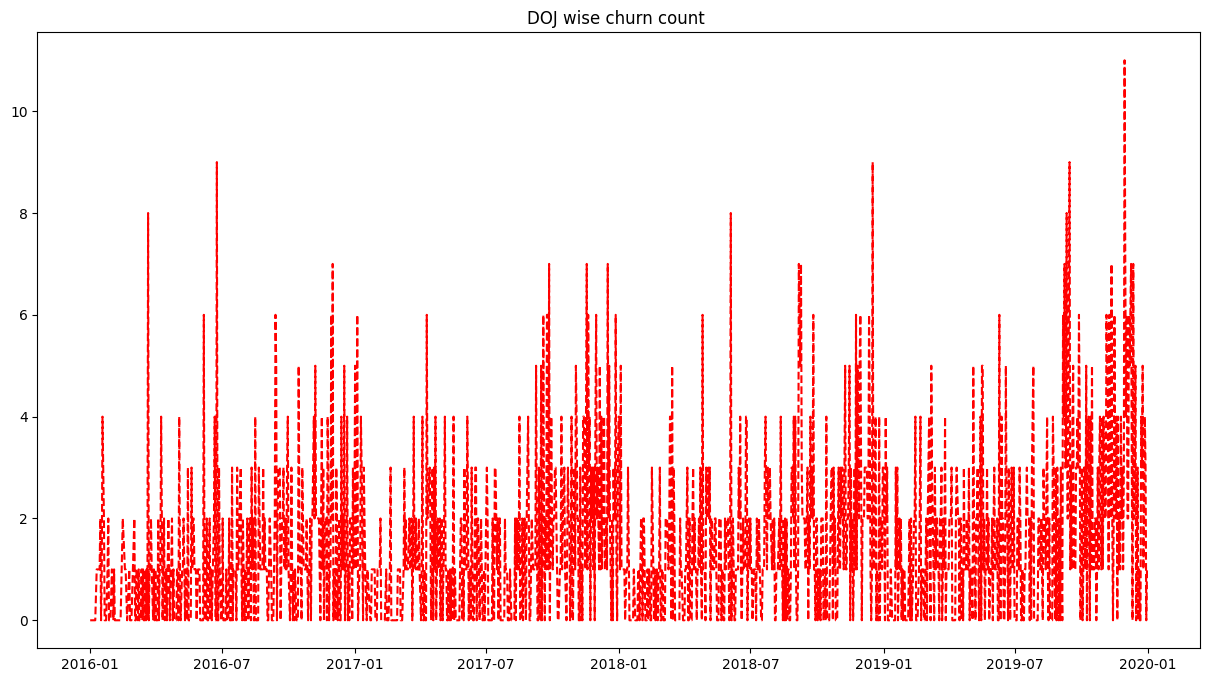

In [ ]:
## step 3.14 : Bivariate Analysis
# show Bank DOJ wise churn count

plt.figure(figsize = (15,8))
plt.title("DOJ wise churn count ")
temp_df = final_df.groupby('Bank DOJ')['Exited'].sum()
x = temp_df.index
y = temp_df.values
plt.plot(x,y,color = 'r', linestyle= '--')
plt.show()

In [ ]:
# 3.15 create m=new column for monthly and weekly analysis

final_df['Month'] = final_df['Bank DOJ'].dt.month_name()
final_df['Day'] = final_df['Bank DOJ'].dt.day_name()

# .dt : means: detection
final_df.sample()



,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory,Month,Day
2163,15667554,605,1,1,35,6,0.0,2,1,1,45206.57,0,2016-12-14,Cameron,France,Male,December,Wednesday


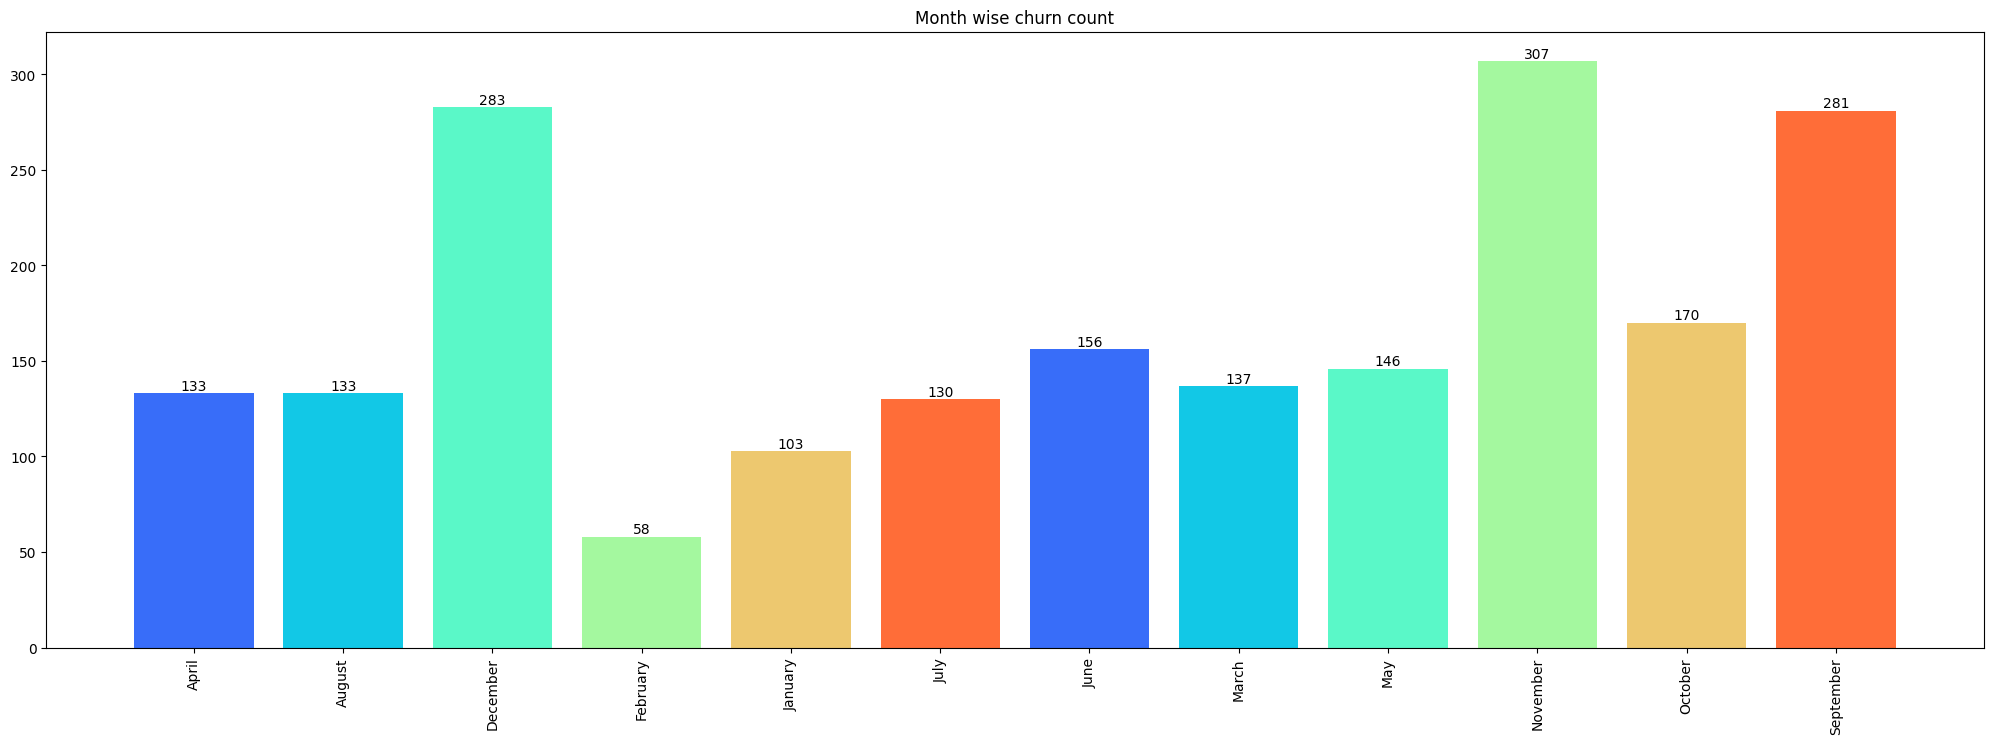

In [ ]:

#step 3.16: show monthly churn analysis

plt.figure(figsize=(25,8))
plt.title("Month wise churn count")
temp_df=final_df.groupby('Month')['Exited'].sum()
x=temp_df.index
y=temp_df.values
ax=plt.bar(x,y,color=sns.color_palette('rainbow'))
plt.bar_label(ax)
plt.xticks(rotation=90)
plt.show()

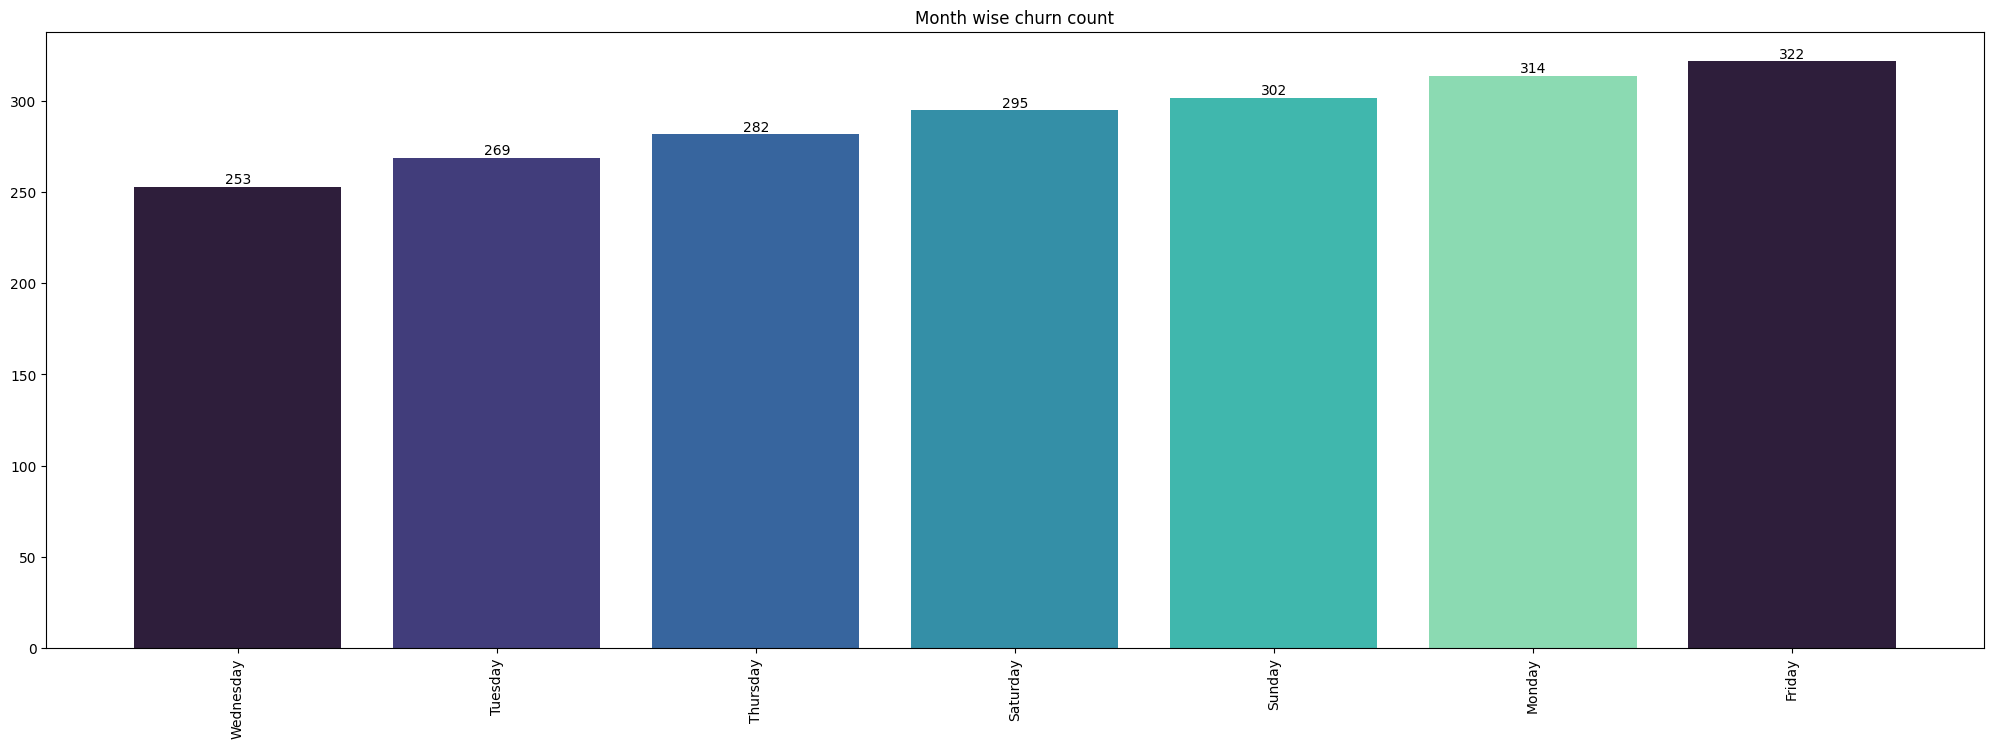

In [ ]:

#step 3.17: show day churn analysis

# step 3.17:: Show Day wise Churn Analysis

plt.figure(figsize=(25,8))
plt.title("Month wise churn count")

temp_df = final_df.groupby('Day')['Exited'].sum().sort_values()

x = temp_df.index
y = temp_df.values

ax = plt.bar(x, y, color=sns.color_palette('mako'))
plt.bar_label(ax)
plt.xticks(rotation=90)

plt.show()

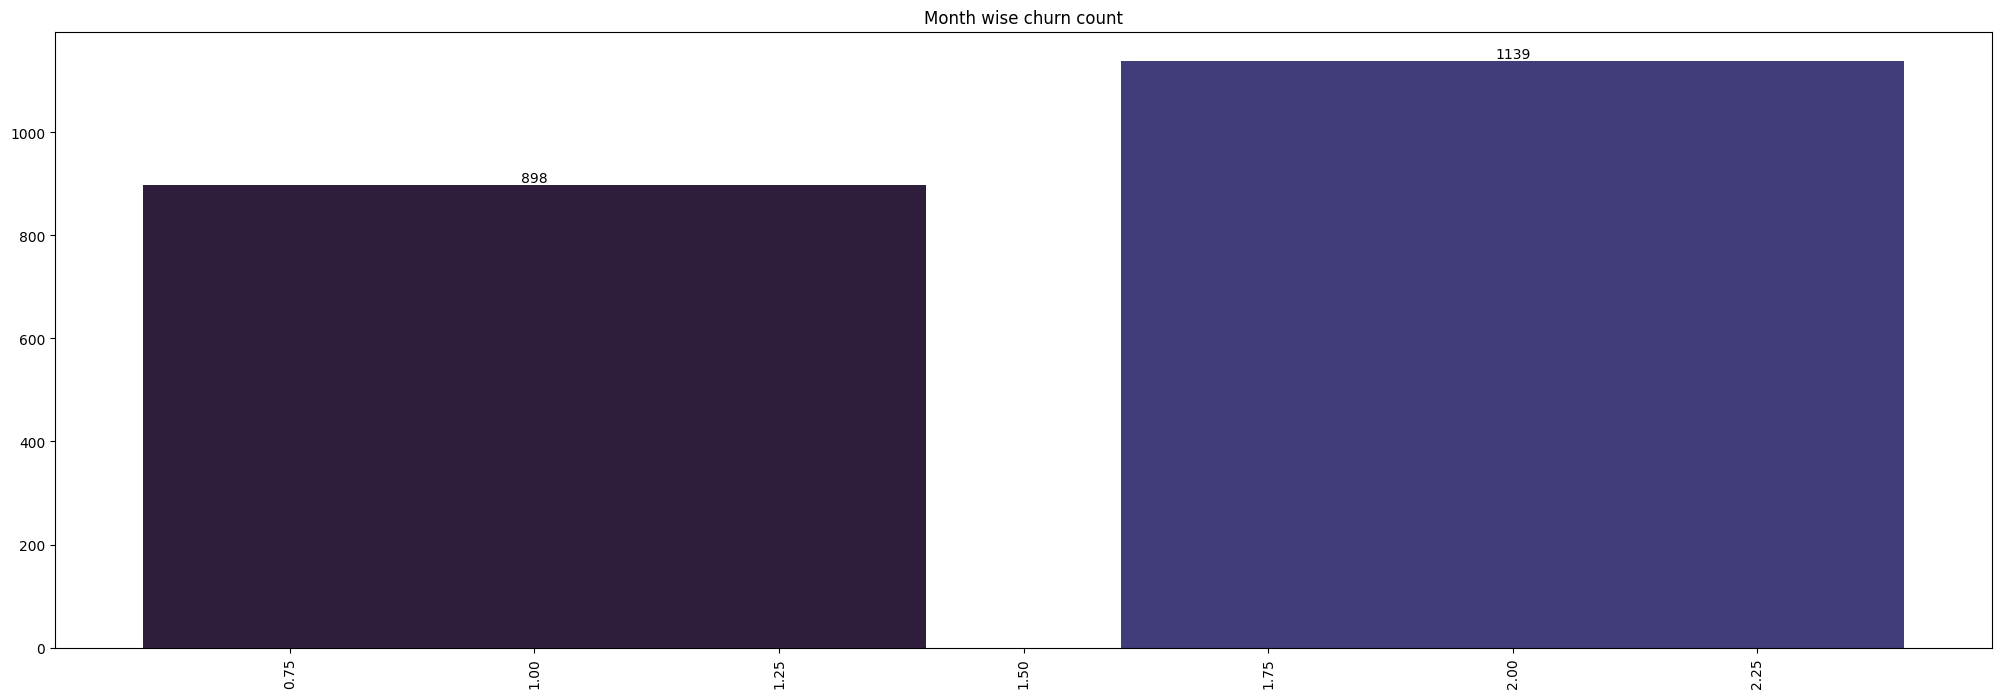

In [ ]:
# 3.18 : genderwise churn analysis
plt.figure(figsize=(25,8))
plt.title("Month wise churn count")

temp_df = final_df.groupby('GenderID')['Exited'].sum().sort_values()

x = temp_df.index
y = temp_df.values

ax = plt.bar(x, y, color=sns.color_palette('mako'))
plt.bar_label(ax)
plt.xticks(rotation=90)

plt.show()

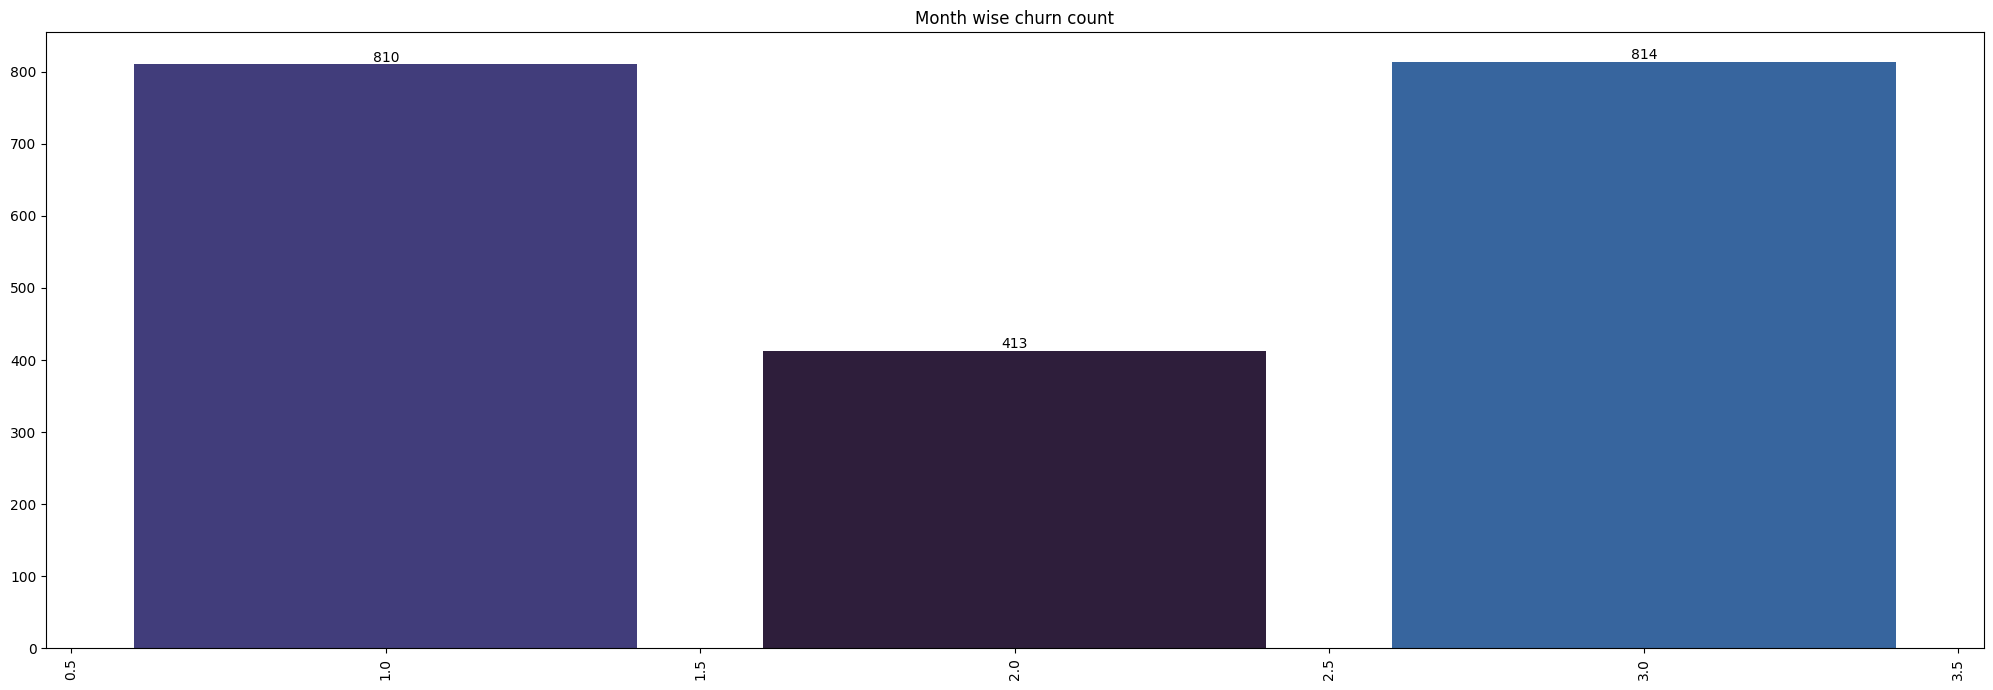

In [ ]:
# 3.19 : GeographyLoaction wise churn analysis
plt.figure(figsize=(25,8))
plt.title("Month wise churn count")

temp_df = final_df.groupby('GeographyID')['Exited'].sum().sort_values()

x = temp_df.index
y = temp_df.values

ax = plt.bar(x, y, color=sns.color_palette('mako'))
plt.bar_label(ax)
plt.xticks(rotation=90)

plt.show()

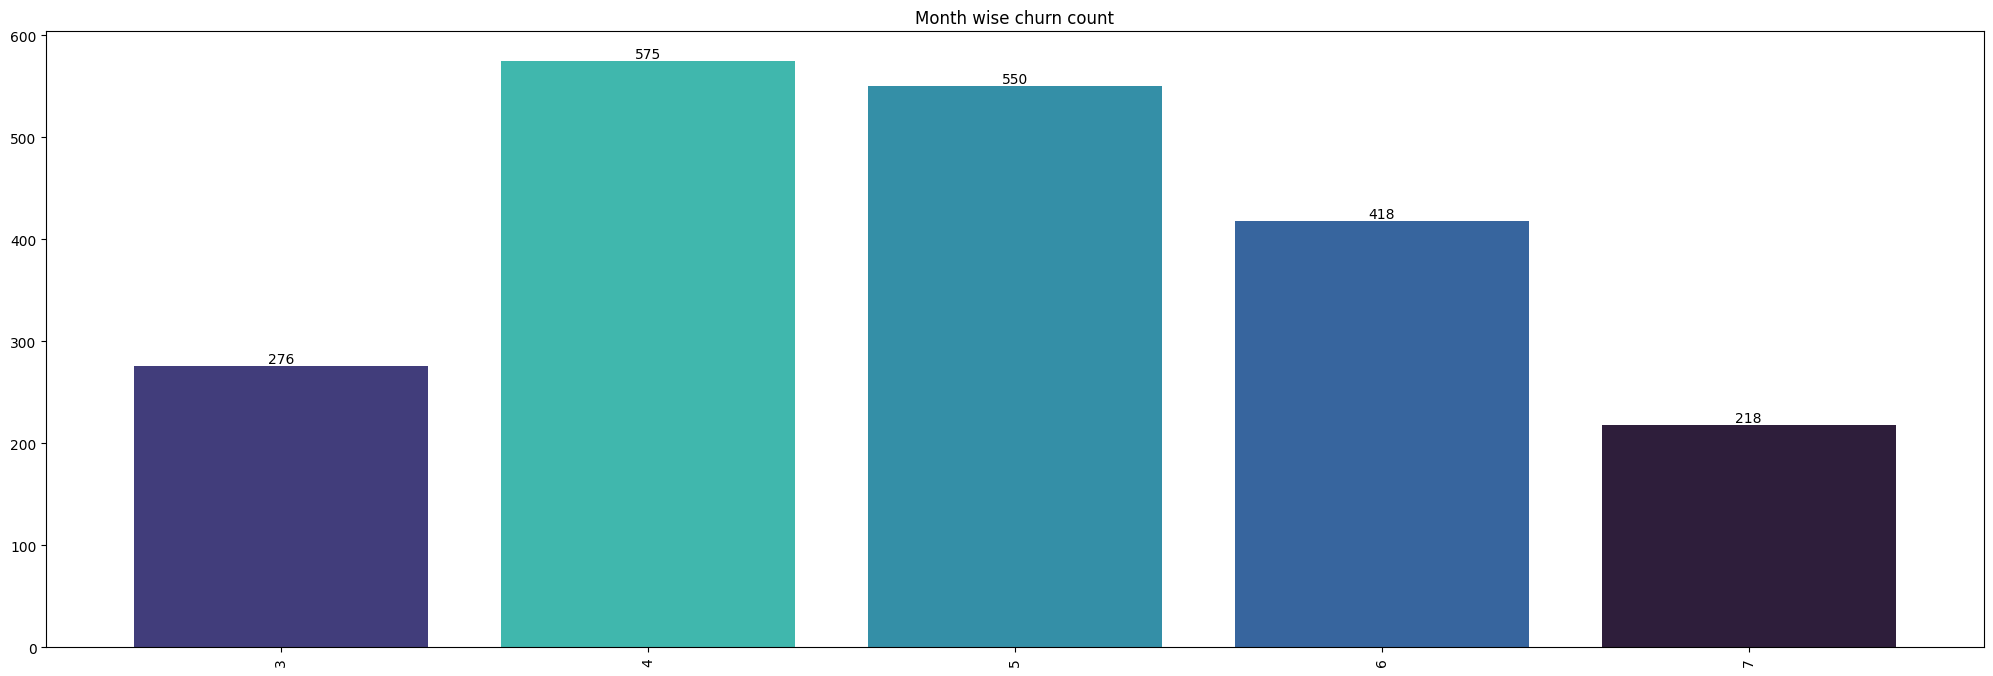

In [ ]:
# 3.20 : tenure wise churn analysis
plt.figure(figsize=(25,8))
plt.title("Month wise churn count")

temp_df = final_df.groupby('Tenure')['Exited'].sum().sort_values()

x = temp_df.index
y = temp_df.values

ax = plt.bar(x, y, color=sns.color_palette('mako'))
plt.bar_label(ax)
plt.xticks(rotation=90)

plt.show()

In [ ]:
ml_drop_columns = ['CustomerId', 'GeographyID', 'GenderID','Bank DOJ', 'Surname', 'Day']
ml_df = final_df.drop(ml_drop_columns, axis =1 , inplace = False)
ml_df.sample()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
8569,622,36,6,0.0,2,1,1,104852.6,0,Spain,Male,August


# Step 4: Feature Engineering

* ML only works with numerical data, if we are getting any textual data
* We need to convert textual data to numerical
* Technique is called feature engineering
* Here GeographyLocation, GenderCategory or Month textual in nature


In [ ]:
# Types of technique
# OHE: one hot encoding
# map: using dict
# apply lambda method
# categorical encoding
# get dummies
# ordinal encoding
# TF-IDF
# BOW: bag of words
# advance: countvectorizer, word embeddings
# more advance: vector database using cosine technique

In [ ]:
# Step 4.1

import calendar

months_name = list(calendar.month_name)[1:]
index = list(range(len(months_name)))
map = dict(zip(months_name, index))

ml_df['Month'] = ml_df['Month'].map(map)
ml_df.sample()

# zip: bind two object together and give dict
# .map: method to map the key with value

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
3534,677,44,6,148770.61,2,1,1,191057.76,0,Germany,Female,0


In [ ]:
ml_df['GeographyLocation'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [ ]:
ml_df['GenderCategory'] = ml_df['GenderCategory'].map({'Male': 0, 'Female': 1})

ml_df['GeographyLocation'] = ml_df['GeographyLocation'].map({
    'France': 0,
    'Spain': 1,
    'Germany': 2
})

ml_df.sample()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
535,608,59,4,0.0,1,1,0,70649.64,1,0,0,8


In [ ]:
# 4.2 Show target value vs feature correlation
ml_df.corr()['Exited'].sort_values(ascending = False)

,Exited
Exited,1.000000
Age,0.285323
GeographyLocation,0.153771
Balance,0.118533
GenderCategory,0.106512
EstimatedSalary,0.012097
Month,0.002312
Tenure,0.000699
HasCrCard,-0.007138
CreditScore,-0.027094


# Step 5: Divide Data into features vs target

In [ ]:
X = ml_df.drop('Exited', axis=1)
y = ml_df['Exited']

# X: must be capital and in DataFrame
# y: must be small and in Series

print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


# Step 6: Divide the data into train and test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=42,
                                                    test_size=0.2)

print("X_train-Shape: ", X_train.shape)
print("X_test-Shape: ", X_test.shape)
print("y_train-Shape: ", y_train.shape)
print("y_test-Shape: ", y_test.shape)

X_train-Shape:  (8000, 11)
X_test-Shape:  (2000, 11)
y_train-Shape:  (8000,)
y_test-Shape:  (2000,)
